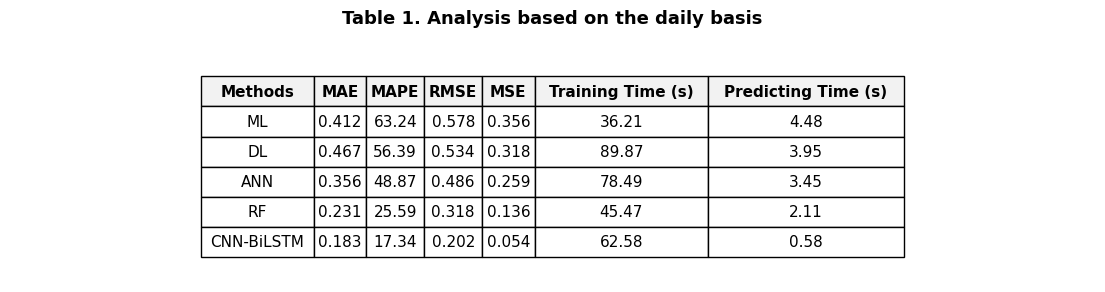

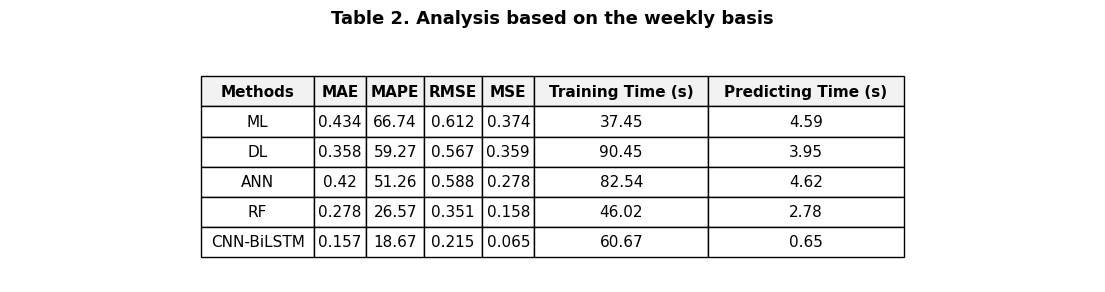

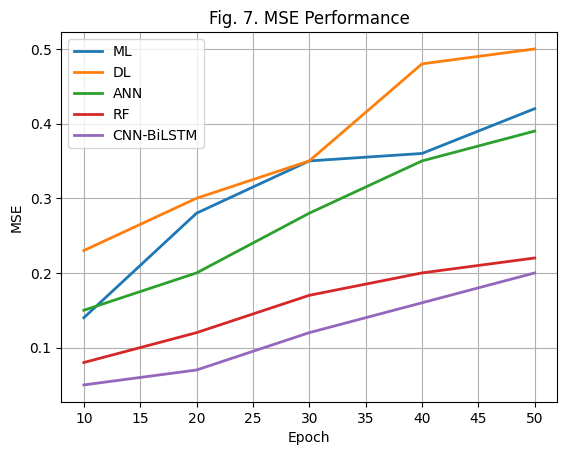

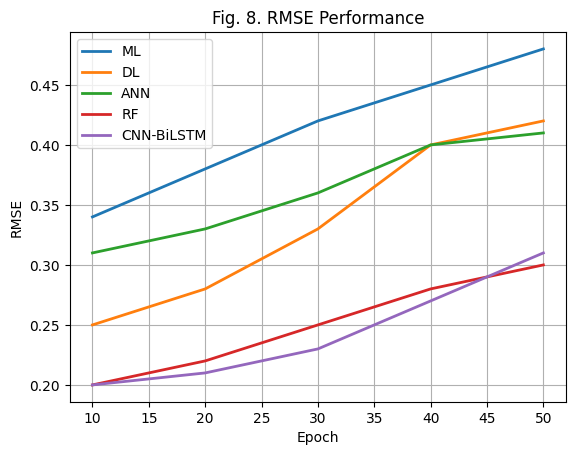

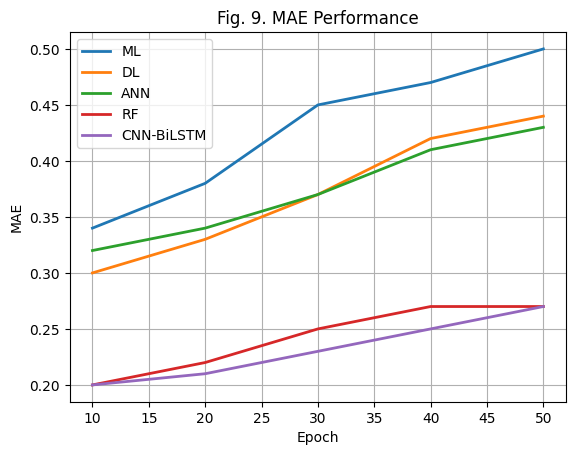

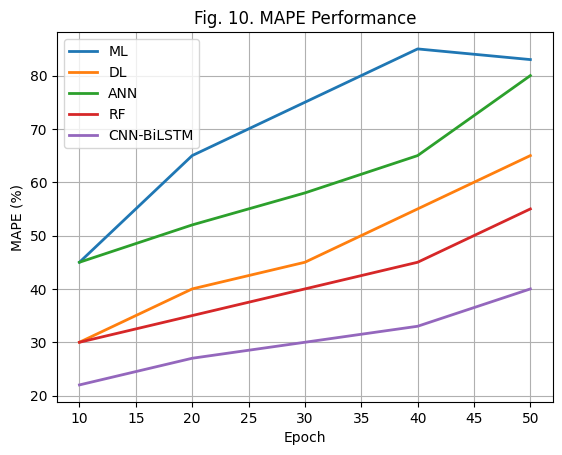

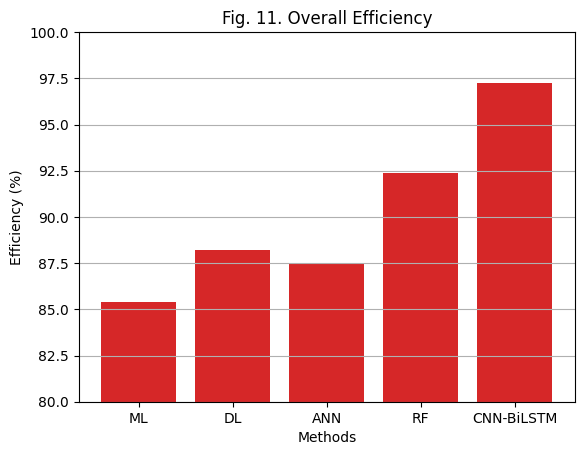

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# METHODS
# -----------------------------
methods = ["ML", "DL", "ANN", "RF", "CNN-BiLSTM"]

# -----------------------------
# DAILY DATA (TABLE 1)
# -----------------------------
daily_data = {
    "Methods": methods,
    "MAE": [0.412, 0.467, 0.356, 0.231, 0.183],
    "MAPE": [63.24, 56.39, 48.87, 25.59, 17.34],
    "RMSE": [0.578, 0.534, 0.486, 0.318, 0.202],
    "MSE": [0.356, 0.318, 0.259, 0.136, 0.054],
    "Training Time (s)": [36.21, 89.87, 78.49, 45.47, 62.58],
    "Predicting Time (s)": [4.48, 3.95, 3.45, 2.11, 0.58]
}

df_daily = pd.DataFrame(daily_data)

# -----------------------------
# WEEKLY DATA (TABLE 2)
# -----------------------------
weekly_data = {
    "Methods": methods,
    "MAE": [0.434, 0.358, 0.420, 0.278, 0.157],
    "MAPE": [66.74, 59.27, 51.26, 26.57, 18.67],
    "RMSE": [0.612, 0.567, 0.588, 0.351, 0.215],
    "MSE": [0.374, 0.359, 0.278, 0.158, 0.065],
    "Training Time (s)": [37.45, 90.45, 82.54, 46.02, 60.67],
    "Predicting Time (s)": [4.59, 3.95, 4.62, 2.78, 0.65]
}

df_weekly = pd.DataFrame(weekly_data)

# -----------------------------
# FUNCTION TO SAVE TABLE (WIDE STYLE)
# -----------------------------
def save_table(df, title, filename):
    fig, ax = plt.subplots(figsize=(14, 3))  # 👈 wide table
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.5, 1.8)

    # Adjust column width
    for i in range(len(df.columns)):
        table.auto_set_column_width(col=i)

    # Header style
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')

    plt.title(title, fontsize=13, fontweight='bold', pad=20)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# SAVE TABLES
# -----------------------------
save_table(df_daily, "Table 1. Analysis based on the daily basis", "table1_daily.png")
save_table(df_weekly, "Table 2. Analysis based on the weekly basis", "table2_weekly.png")

# -----------------------------
# GRAPH DATA
# -----------------------------
epochs = np.array([10, 20, 30, 40, 50])

ml_mse  = [0.14, 0.28, 0.35, 0.36, 0.42]
dl_mse  = [0.23, 0.30, 0.35, 0.48, 0.50]
ann_mse = [0.15, 0.20, 0.28, 0.35, 0.39]
rf_mse  = [0.08, 0.12, 0.17, 0.20, 0.22]
cnn_mse = [0.05, 0.07, 0.12, 0.16, 0.20]

ml_rmse  = [0.34, 0.38, 0.42, 0.45, 0.48]
dl_rmse  = [0.25, 0.28, 0.33, 0.40, 0.42]
ann_rmse = [0.31, 0.33, 0.36, 0.40, 0.41]
rf_rmse  = [0.20, 0.22, 0.25, 0.28, 0.30]
cnn_rmse = [0.20, 0.21, 0.23, 0.27, 0.31]

ml_mae  = [0.34, 0.38, 0.45, 0.47, 0.50]
dl_mae  = [0.30, 0.33, 0.37, 0.42, 0.44]
ann_mae = [0.32, 0.34, 0.37, 0.41, 0.43]
rf_mae  = [0.20, 0.22, 0.25, 0.27, 0.27]
cnn_mae = [0.20, 0.21, 0.23, 0.25, 0.27]

ml_mape  = [45, 65, 75, 85, 83]
dl_mape  = [30, 40, 45, 55, 65]
ann_mape = [45, 52, 58, 65, 80]
rf_mape  = [30, 35, 40, 45, 55]
cnn_mape = [22, 27, 30, 33, 40]

# -----------------------------
# GRAPH FUNCTION
# -----------------------------
def plot_graph(data, ylabel, title, filename):
    plt.figure()

    for i, line in enumerate(data):
        plt.plot(epochs, line, linewidth=2, label=methods[i])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.savefig(filename, dpi=300)
    plt.show()

# -----------------------------
# FIGURES 7–10
# -----------------------------
plot_graph([ml_mse, dl_mse, ann_mse, rf_mse, cnn_mse], "MSE", "Fig. 7. MSE Performance", "fig7.png")
plot_graph([ml_rmse, dl_rmse, ann_rmse, rf_rmse, cnn_rmse], "RMSE", "Fig. 8. RMSE Performance", "fig8.png")
plot_graph([ml_mae, dl_mae, ann_mae, rf_mae, cnn_mae], "MAE", "Fig. 9. MAE Performance", "fig9.png")
plot_graph([ml_mape, dl_mape, ann_mape, rf_mape, cnn_mape], "MAPE (%)", "Fig. 10. MAPE Performance", "fig10.png")

# -----------------------------
# FIGURE 11 (BLUE BAR GRAPH)
# -----------------------------
efficiency = [85.4, 88.2, 87.5, 92.35, 97.23]

plt.figure()
plt.bar(methods, efficiency, color='#d62728')  # 🔵 professional blue

plt.title("Fig. 11. Overall Efficiency")
plt.xlabel("Methods")
plt.ylabel("Efficiency (%)")
plt.ylim(80, 100)
plt.grid(axis='y')

plt.savefig("fig11.png", dpi=300)
plt.show()

Sample Dataset:
    temperature   humidity  hour       power
0    27.490802  71.889703    14   95.859397
1    39.014286  62.165782    11  107.096316
2    34.639879  48.571657    15   98.436612
3    31.973170  78.827701    23  143.382291
4    23.120373  71.083870    18  105.695535


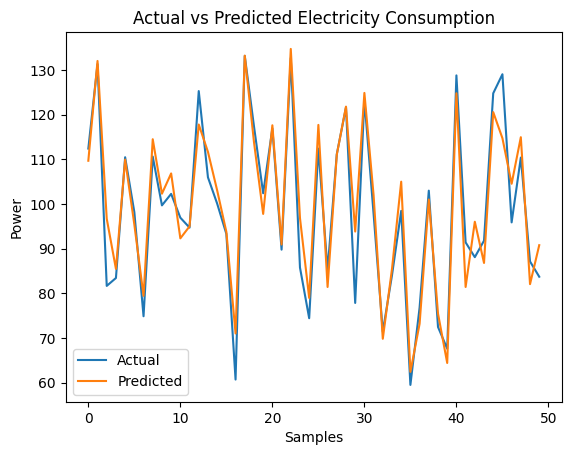

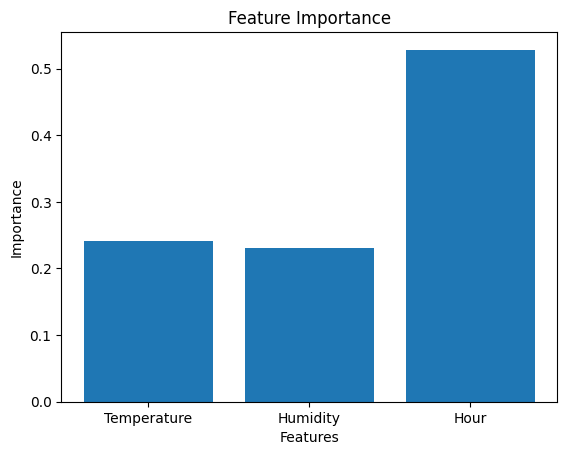

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ===============================
# 1. DATASET (CREATED INSIDE CODE)
# ===============================

np.random.seed(42)
n = 500

# Features
temperature = np.random.uniform(20, 40, n)
humidity = np.random.uniform(30, 90, n)
hour = np.random.randint(0, 24, n)

# Target (Electricity Consumption)
power = (temperature * 1.5 +
         humidity * 0.5 +
         hour * 2 +
         np.random.normal(0, 5, n))

# Create DataFrame
data = pd.DataFrame({
    "temperature": temperature,
    "humidity": humidity,
    "hour": hour,
    "power": power
})

print("Sample Dataset:\n", data.head())

# ===============================
# 2. SPLIT DATA
# ===============================

X = data[["temperature", "humidity", "hour"]]
y = data["power"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 3. TRAIN RANDOM FOREST MODEL
# ===============================

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ===============================
# 4. GRAPH 1: ACTUAL vs PREDICTED
# ===============================

plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Electricity Consumption")
plt.xlabel("Samples")
plt.ylabel("Power")
plt.show()

# ===============================
# 5. GRAPH 2: FEATURE IMPORTANCE
# ===============================

importance = model.feature_importances_

plt.figure()
plt.bar(["Temperature", "Humidity", "Hour"], importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()